In [1]:
import math
import time
import joblib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from utils import load_images
from sklearn.datasets import load_digits
from sklearn.decomposition import FastICA
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

/usr/local/lib/python3.8/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ica_model_fname = "fastica_25x25_100_logcosh.joblib"
ica_model = joblib.load(ica_model_fname)

In [3]:
mixing_matrix = ica_model.mixing_
print(mixing_matrix.shape)

(625, 100)


In [4]:
augmented_mixing_matrix = np.concatenate((mixing_matrix, -mixing_matrix), axis=1)
print(augmented_mixing_matrix.shape)

(625, 200)


In [5]:
fname = "fastica_25x25_100_logcosh_aug.npy"
np.save(fname, augmented_mixing_matrix)

In [12]:
images = load_images()
images = images.reshape(images.shape[0], -1)
train_image_size = 20_000
train_images = images[:train_image_size]

In [13]:
train_z = ica_model.transform(train_images)

In [14]:
train_z_aug = np.concatenate((np.maximum(0, train_z), np.maximum(-train_z, 0)), axis=1)

In [15]:
x_orig = train_z @ mixing_matrix.T
print(x_orig.shape)
x_aug = train_z_aug @ augmented_mixing_matrix.T
print(x_aug.shape)

(20000, 625)
(20000, 625)


In [16]:
tiny = np.finfo(x_orig.dtype).tiny
print(np.isclose(x_orig, x_aug).all())
print(np.allclose(x_orig, x_aug, atol=tiny))

True
True


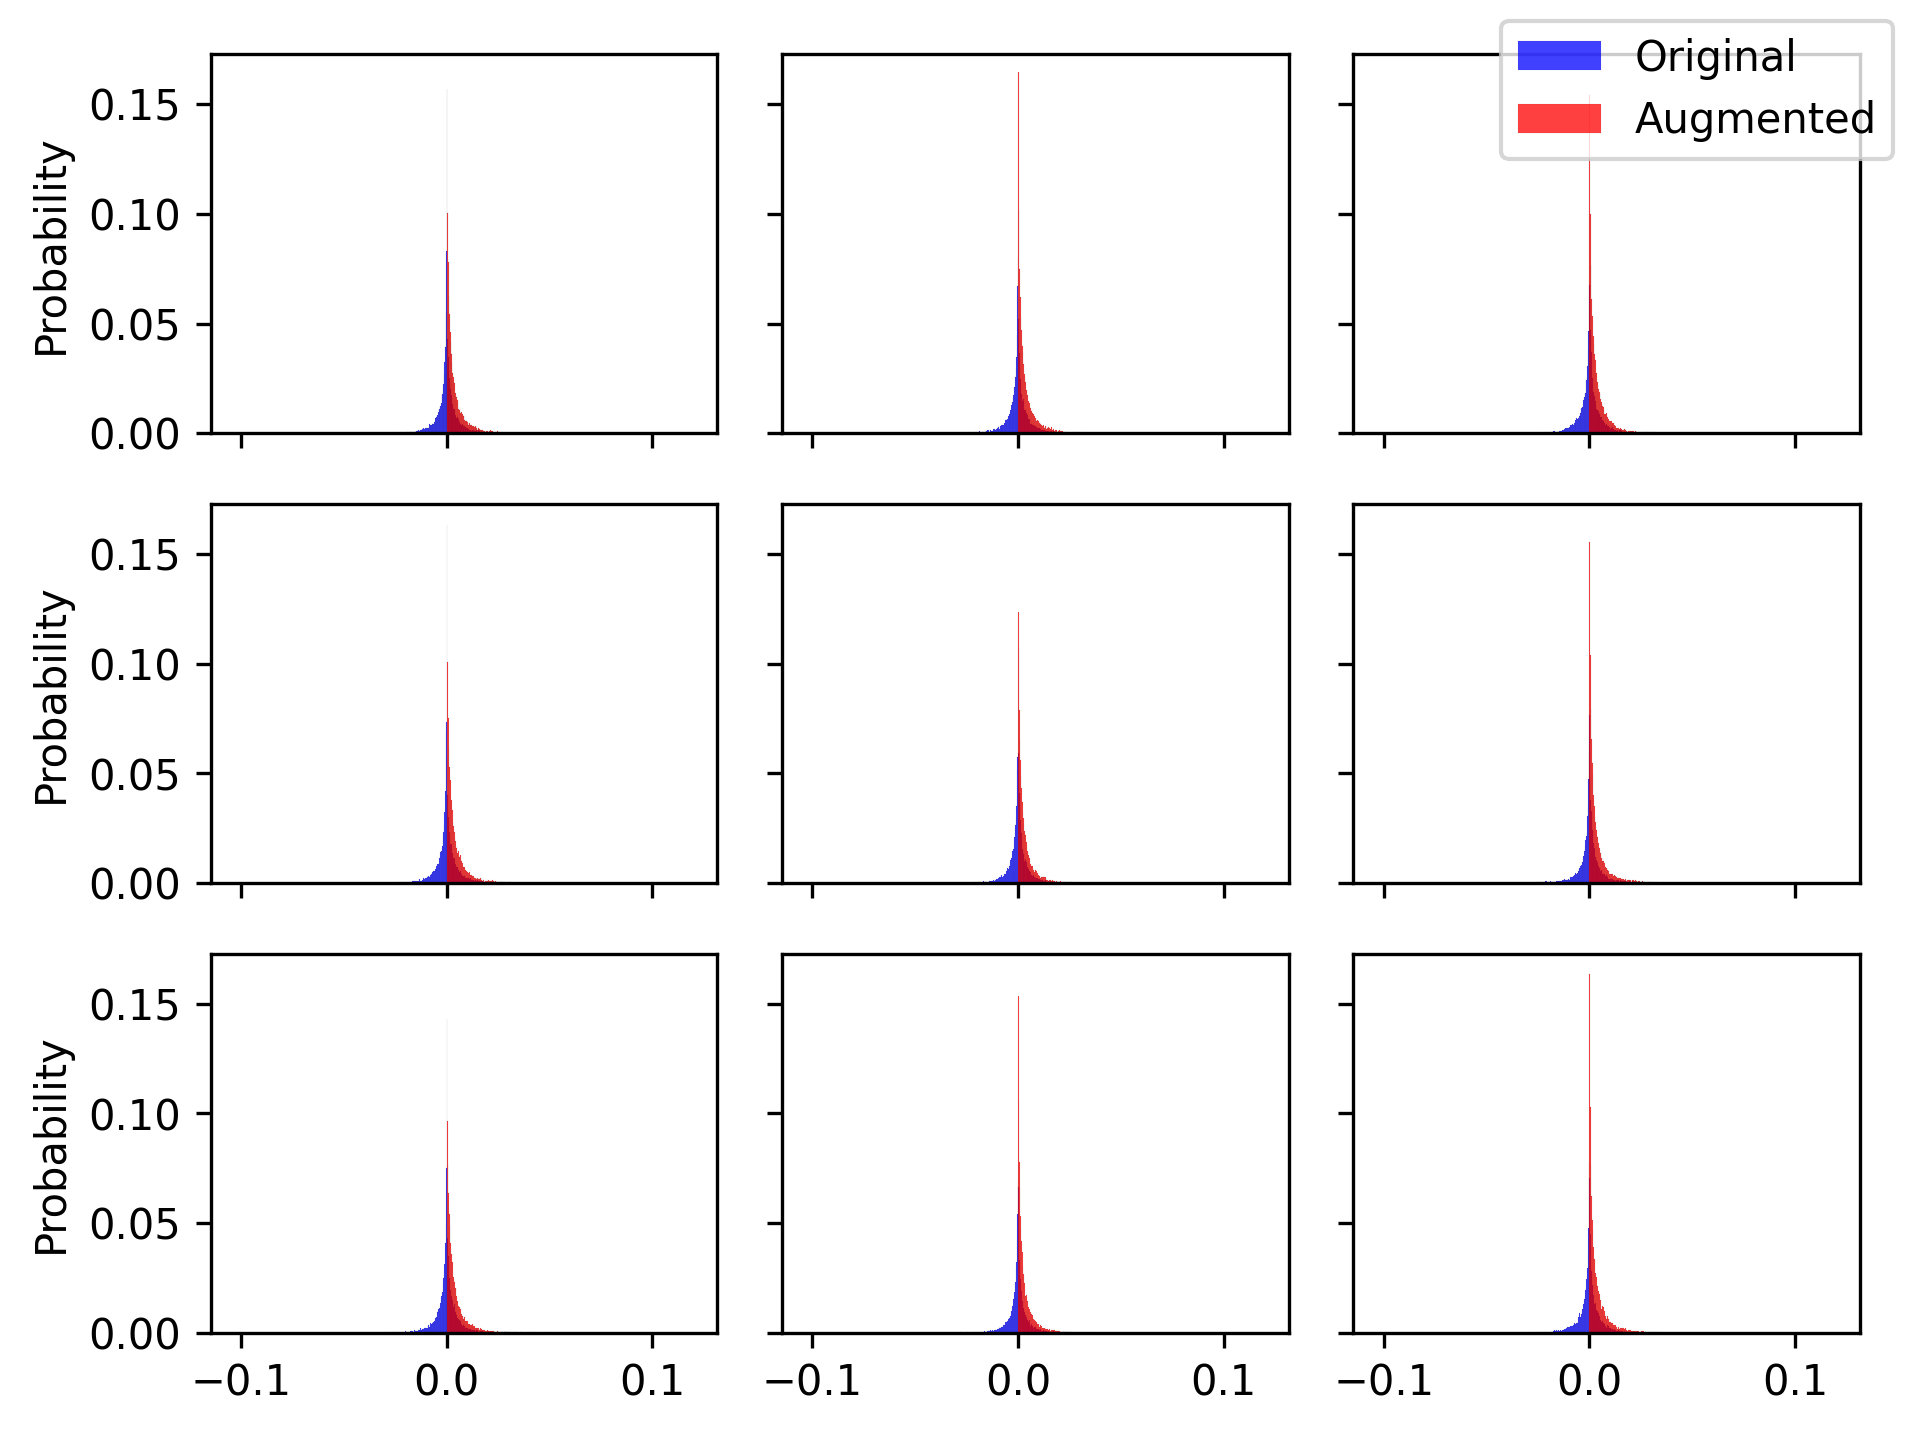

In [17]:
fig, axs = plt.subplots(3, 3, dpi=300, sharex=True, sharey=True, tight_layout=True)
for orig_values, new_values_1, new_values_2, ax in zip(
    train_z.T, train_z_aug.T[:100], train_z_aug.T[100:], axs.flatten()
):
    sns.histplot(
        orig_values,
        ax=ax,
        stat="probability",
        color="blue",
        label="Original",
    )

    sns.histplot(
        new_values_1 + new_values_2,
        ax=ax,
        stat="probability",
        color="red",
        label="Augmented",
    )
    # ax.axis("off")
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

KeyboardInterrupt: 

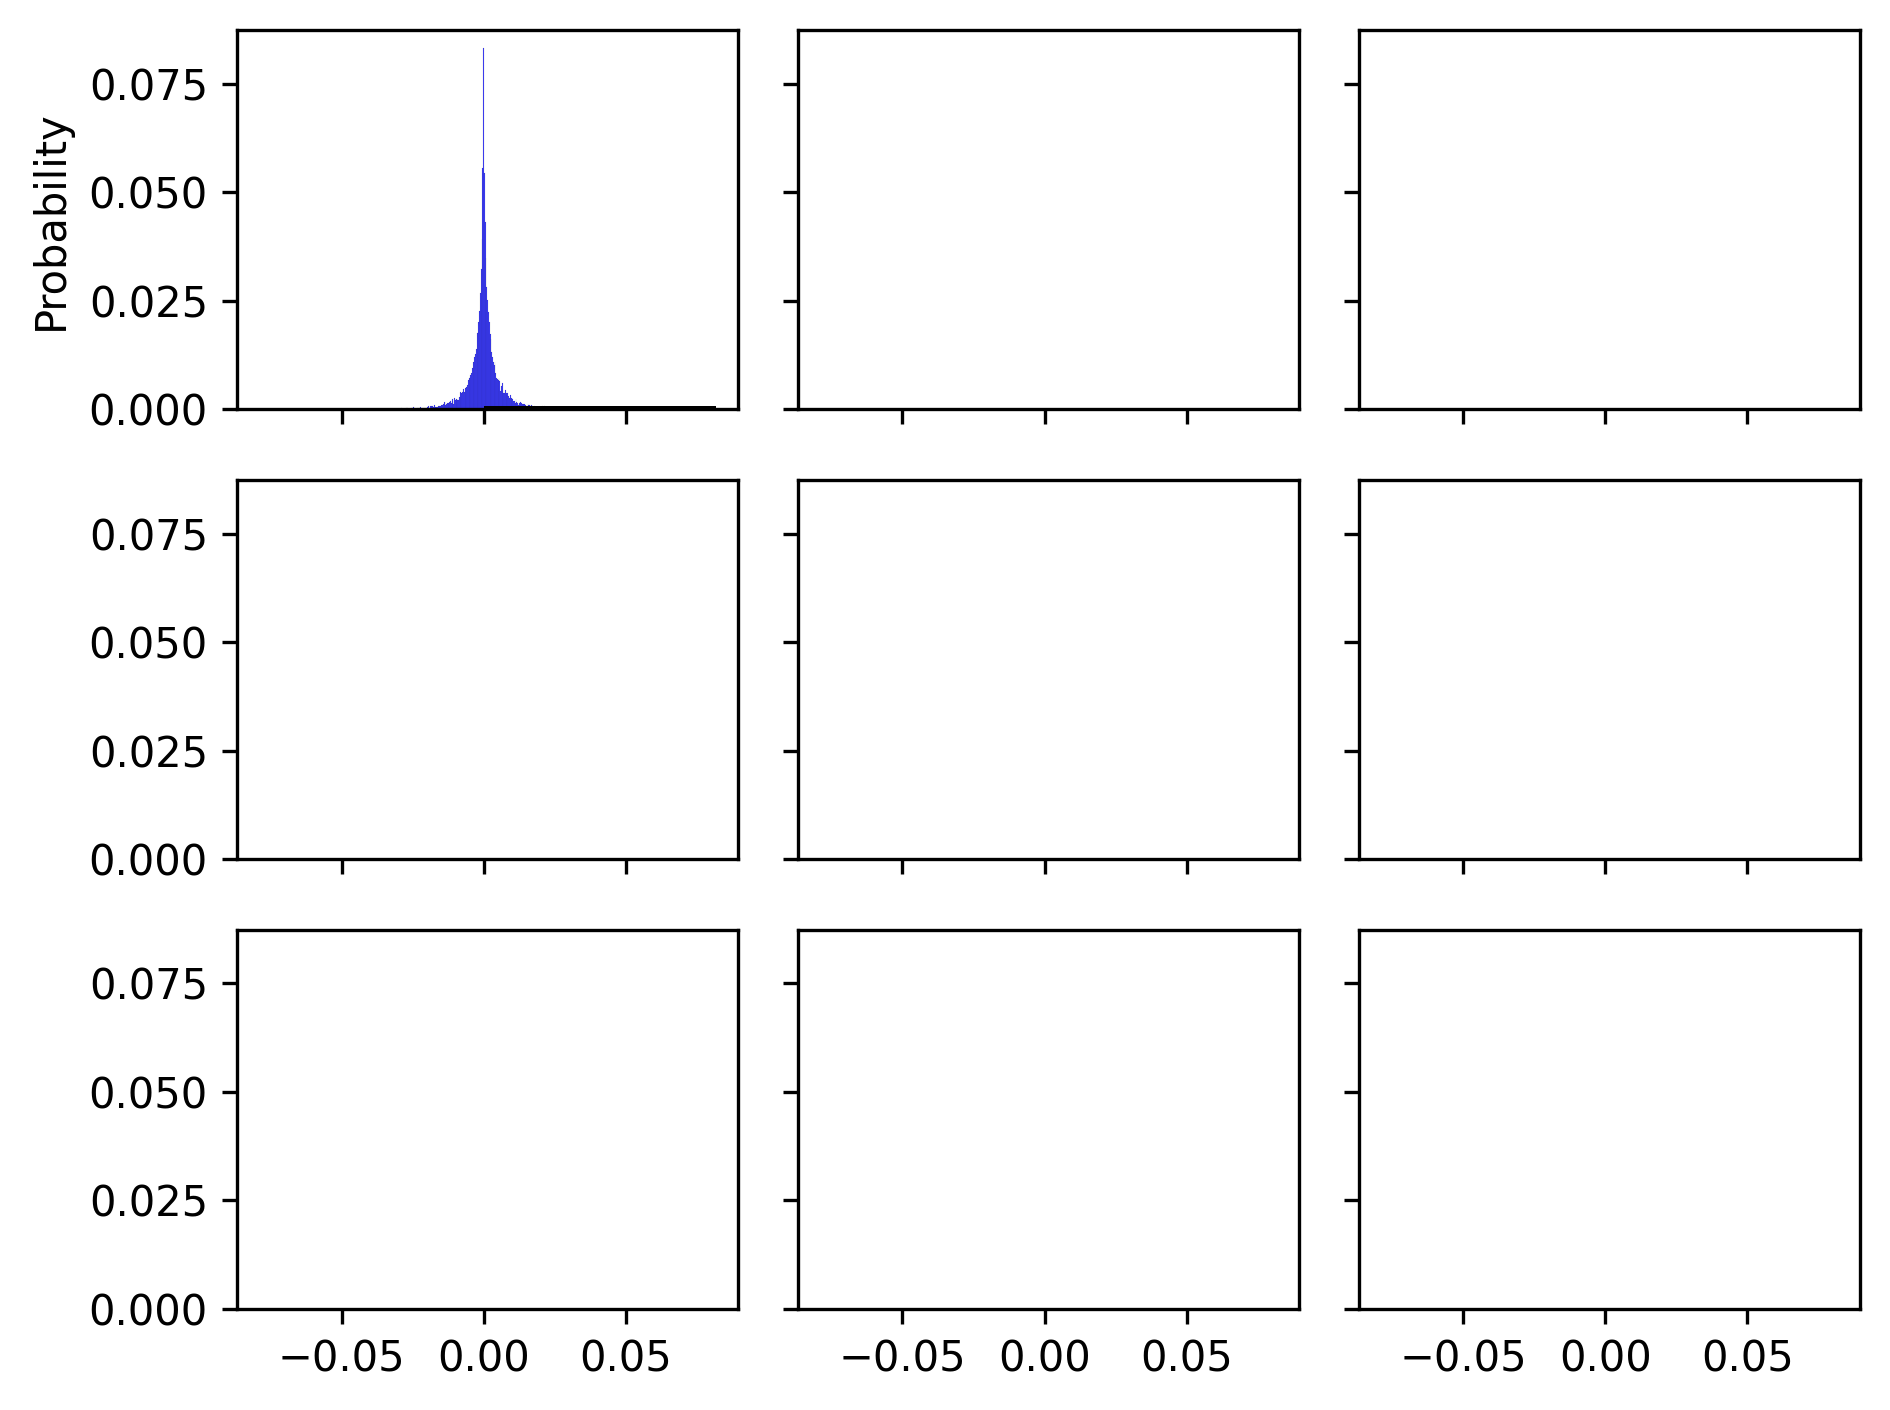

In [18]:
fig, axs = plt.subplots(3, 3, dpi=300, sharex=True, sharey=True, tight_layout=True)
for orig_values, new_values_1, new_values_2, ax in zip(
    train_z.T, train_z_aug.T[:100], train_z_aug.T[100:], axs.flatten()
):
    sns.histplot(
        orig_values,
        ax=ax,
        stat="probability",
        color="blue",
        label="Original",
    )

    sns.histplot(
        np.array([new_values_1, new_values_2]),
        ax=ax,
        stat="probability",
        color="red",
        label="Augmented",
    )
    ax.set_xlim(-0.05, 0.05)
    # ax.axis("off")
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")